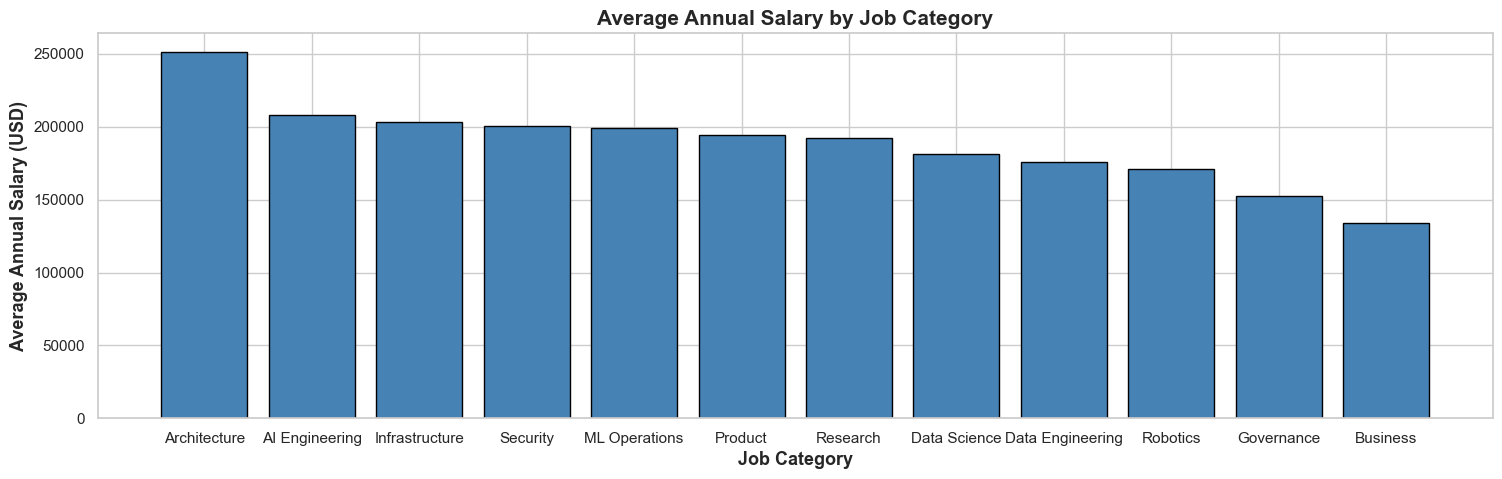

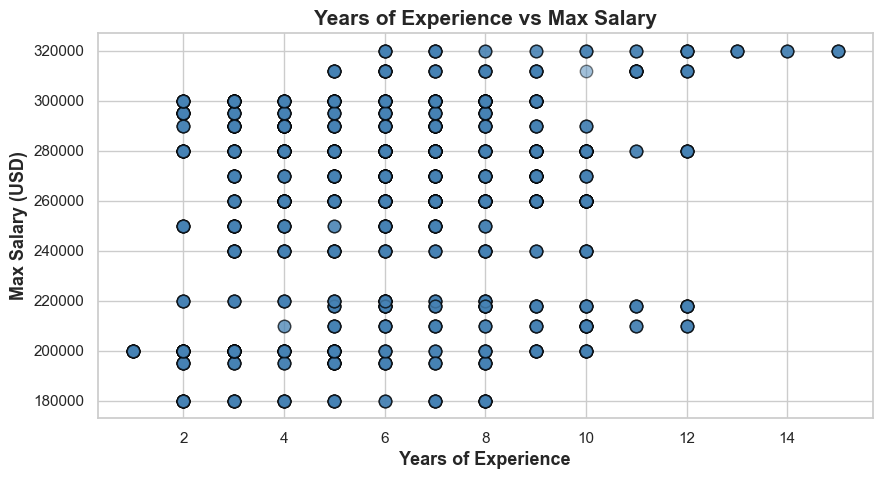

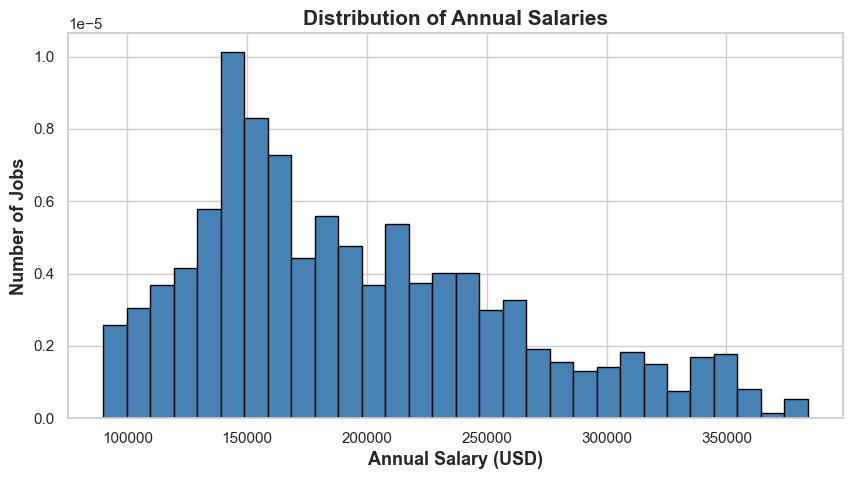

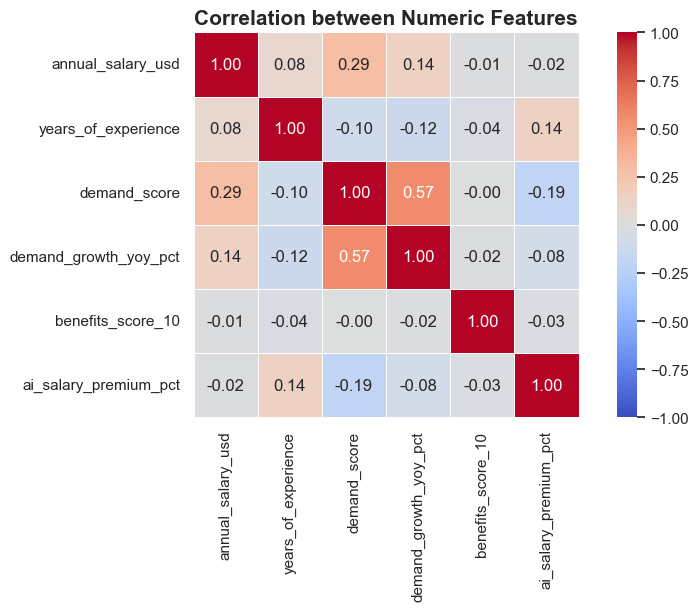

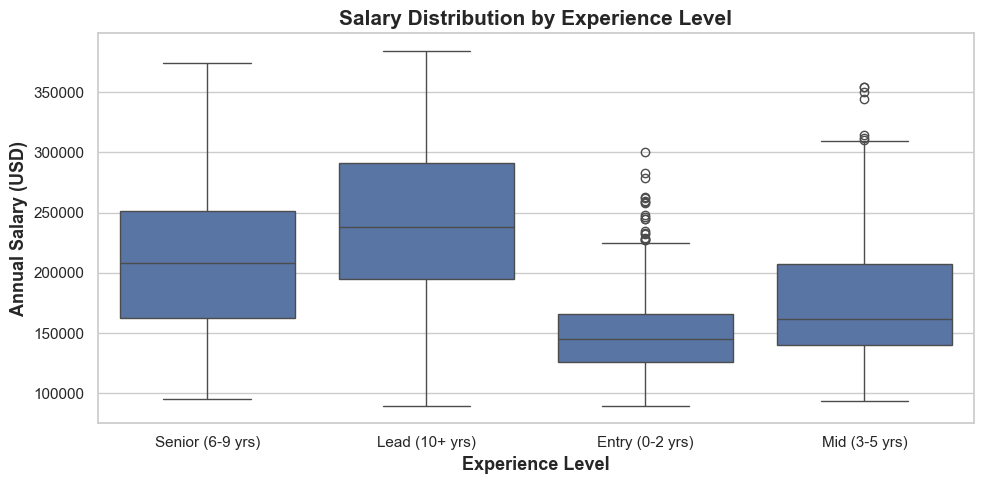

In [ ]:
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Download latest version
path = kagglehub.dataset_download("alitaqishah/ai-jobs-market-2025-2026-salaries")

#Check the dataset
dataset = pd.read_csv(path + '/ai_jobs_market_2025_2026.csv')
# print(dataset.head())
# print(dataset.info())
# print(dataset.describe())
# print(dataset.isnull())

#Ask 5 questions about data
questions = np.array(['Which is the average annual salary for each job category?', 
                      'Is there any relationship between max salary and years of experience?', 
                      'How many jobs are available for different annual salaries?',
                      'What is the correlation between different numeric quantities?',
                      'How are annual salaries ditributed across experience levels?'])

fig, ax = plt.subplots(figsize = (18, 5))
avg_salary = dataset.groupby('job_category')['annual_salary_usd'].mean().sort_values(ascending=False)
ax.bar(avg_salary.index, avg_salary.values, color = 'steelblue', edgecolor = 'black', width=0.8)
ax.set_title("Average Annual Salary by Job Category", fontsize = 15, fontweight = 'bold')
ax.set_xlabel("Job Category", fontsize = 13, fontweight = 'bold')
ax.set_ylabel("Average Annual Salary (USD)", fontsize = 13, fontweight = 'bold')

fig, ax = plt.subplots(figsize = (10, 5))
ax.scatter(dataset.loc[:, 'years_of_experience'], dataset.loc[:, 'salary_max_usd'], color= 'steelblue', edgecolors='black', alpha=0.5, s= 80)
ax.set_title("Years of Experience vs Max Salary", fontsize = 15, fontweight = 'bold')
ax.set_xlabel("Years of Experience", fontsize = 13, fontweight = 'bold')
ax.set_ylabel("Max Salary (USD)", fontsize = 13, fontweight = 'bold')

fig, ax = plt.subplots(figsize = (10, 5))
ax.hist(dataset.loc[:, 'annual_salary_usd'], bins = 30, color = 'steelblue', edgecolor = 'black', density = True)
ax.set_title("Distribution of Annual Salaries", fontsize = 15, fontweight = 'bold')
ax.set_xlabel("Annual Salary (USD)", fontsize = 13, fontweight = 'bold')
ax.set_ylabel("Number of Jobs", fontsize = 13, fontweight = 'bold')

fig, ax = plt.subplots(figsize = (10, 5))
numeric_cols = ['annual_salary_usd', 'years_of_experience', 'demand_score', 'demand_growth_yoy_pct', 'benefits_score_10', 'ai_salary_premium_pct']
corr = dataset[numeric_cols].corr()
sns.heatmap(corr, annot= True, fmt = '.2f', vmax=1, vmin=-1, cmap= 'coolwarm', square = True, linewidths=0.5, ax=ax)
ax.set_title("Correlation between Numeric Features", fontsize = 15, fontweight = 'bold')

fig, ax = plt.subplots(figsize = (10, 5))
order = dataset.groupby('experience_level')['annual_salay_usd'].median().sort_values(ascending=False).index
sns.boxplot(dataset, x = 'experience_level', y = 'annual_salary_usd', order = order, ax=ax)
ax.set_title("Salary Distribution by Experience Level", fontsize = 15, fontweight = 'bold')
ax.set_xlabel("Experience Level", fontsize = 13, fontweight = 'bold')
ax.set_ylabel("Annual Salary (USD)", fontsize = 13, fontweight = 'bold')

plt.tight_layout()
plt.show()


